# Datavalidation

The Data has been created for 14.400 Buildings via a highly customized version of [TSIB](https://github.com/NV717/tsorb_simuflex). Before any further proceedings the validity of the generated data itself and its distribution is checked.

## ToDo

1. Check all runs completed/ which failed
2. Check generated results have same parameters as manifest and distribution
3. check timeseries for missing values/negative values/ problems and if distribution makes sense
4. check for identical timeseries

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import ast
from itertools import chain
from collections import Counter
from DataPreparationHelper import *
from tqdm import tqdm

RESULTS_DIR = Path(r"Generation\Generation\Test")
test_path = r"Generation/Generation/run_000013.h5"
MANIFEST_PATH = r"manifest.parquet"

In [10]:
manifest = pd.read_parquet(MANIFEST_PATH)
#manifest = manifest.iloc[:361]

In [11]:
manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,nightReduction,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed
0,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,True,False,21.0,24.0,1,False,0,run_000000,1000000
1,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,True,False,21.0,24.0,1,False,0,run_000001,1000001
2,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,True,False,21.0,24.0,1,False,0,run_000002,1000002
3,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,"[1, 3, 2, 2, 1, 1, 4, 1, 1, 1, 2, 4, 1, 4, 1, ...",...,True,True,False,21.0,24.0,1,False,1,run_000003,1000003
4,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,"[1, 3, 2, 2, 1, 1, 4, 1, 1, 1, 2, 4, 1, 4, 1, ...",...,True,True,False,21.0,24.0,1,False,1,run_000004,1000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,DE,TH,Semi,DE.12,160.8,1,hot,False,12,[4],...,True,True,False,21.0,24.0,1,False,4798,run_014395,1014395
14396,DE,TH,Semi,DE.12,160.8,1,hot,False,12,[4],...,True,True,False,21.0,24.0,1,False,4798,run_014396,1014396
14397,DE,TH,Semi,DE.12,58.1,1,hot,False,14,[1],...,True,True,False,21.0,24.0,1,False,4799,run_014397,1014397
14398,DE,TH,Semi,DE.12,58.1,1,hot,False,14,[1],...,True,True,False,21.0,24.0,1,False,4799,run_014398,1014398


In [12]:
completed_runs = RESULTS_DIR.glob("run_*.h5")
dfs = [pd.read_hdf(run, key="params") for run in completed_runs]
realised_manifest = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [13]:
realised_manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,seed,weatherFilepath,weatherID,resolved_climateRegion,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,maxLoadViolation_kW,runtime_seconds
0,DE,SFH,Detached,DE.01,104.9,1,cold,False,10,[2],...,1006400,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2015_10_cold_TRY2015_509011147952_Wint,10,50.9011,14.7952,1006400,[367265],3.518052e-09,56.125044
1,DE,SFH,Detached,DE.01,104.9,1,cold,False,10,[2],...,1006401,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2015_10_cold_TRY2015_501319121655_Wint,10,50.1319,12.1655,1006401,[7277263],7.402864e-10,61.922931
2,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,1006402,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2015_15_cold_TRY2015_477287126404_Wint,15,47.7287,12.6404,1006402,[6448275],1.414609e-10,67.878528
3,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,1006403,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2015_15_cold_TRY2015_476180129649_Wint,15,47.6180,12.9649,1006403,[7046360],2.389257e-12,59.195814
4,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,1006404,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2015_15_cold_TRY2015_536599098044_Wint,15,53.6599,9.8044,1006404,[9774458],1.877357e-14,66.593754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,DE,SFH,Detached,DE.02,82.4,1,cold,True,5,[4],...,1006695,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2045_5_cold_TRY2045_517028065312_Wint,5,51.7028,6.5312,1006695,[5266842],1.084655e-12,61.104747
296,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,1006696,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2045_4_cold_TRY2045_514439116609_Wint,4,51.4439,11.6609,1006696,[4652124],4.999674e-11,58.950961
297,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,1006697,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2045_4_cold_TRY2045_514439116609_Wint,4,51.4439,11.6609,1006697,[9737547],1.639606e-10,55.886976
298,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,1006698,/home/ss7446s@ad.fh-aachen.de/Dokumente/tsib_g...,TRY2045_4_cold_TRY2045_517601142841_Wint,4,51.7601,14.2841,1006698,[225748],3.757987e-09,60.568235


In [14]:
realised_manifest_cut = pd.concat([realised_manifest.iloc[:56], realised_manifest.iloc[60:341], realised_manifest.iloc[342:]])

In [15]:
manifest[manifest["seed"].isin(realised_manifest["seed"])]

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,nightReduction,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed
6400,DE,SFH,Detached,DE.01,104.9,1,cold,False,10,[2],...,True,True,False,21.0,24.0,1,False,2133,run_006400,1006400
6401,DE,SFH,Detached,DE.01,104.9,1,cold,False,10,[2],...,True,True,False,21.0,24.0,1,False,2133,run_006401,1006401
6402,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,True,True,False,21.0,24.0,1,False,2134,run_006402,1006402
6403,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,True,True,False,21.0,24.0,1,False,2134,run_006403,1006403
6404,DE,SFH,Detached,DE.01,165.6,1,cold,False,15,[4],...,True,True,False,21.0,24.0,1,False,2134,run_006404,1006404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6695,DE,SFH,Detached,DE.02,82.4,1,cold,True,5,[4],...,True,True,False,21.0,24.0,1,False,2231,run_006695,1006695
6696,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,True,True,False,21.0,24.0,1,False,2232,run_006696,1006696
6697,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,True,True,False,21.0,24.0,1,False,2232,run_006697,1006697
6698,DE,SFH,Detached,DE.02,131.8,1,cold,True,4,[1],...,True,True,False,21.0,24.0,1,False,2232,run_006698,1006698


Planned: 14400
Realized: 296
Missing Cols: 14104
Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       14390, 14391, 14392, 14393, 14394, 14395, 14396, 14397, 14398, 14399],
      dtype='int64', length=14104)
Planned and Realized Values are identical: True
Planned and Realized Differences: Empty DataFrame
Columns: []
Index: []
overview planned================================================================================
Overview
Rows: 296
Unique buildings: 97
Unique runs: 296
MISSING VALUES
country            0
buildingType       0
surrounding        0
buildingAgeBin     0
a_ref              0
n_apartments       0
year_type          0
future             0
climateRegion      0
n_persons          0
freq               0
hasFirePlace       0
varyoccupancy      0
mean_load          0
nightReduction     0
capControl         0
occControl         0
comfortT_lb        0
comfortT_ub        0
cores              0
useCache           0
building_id        0

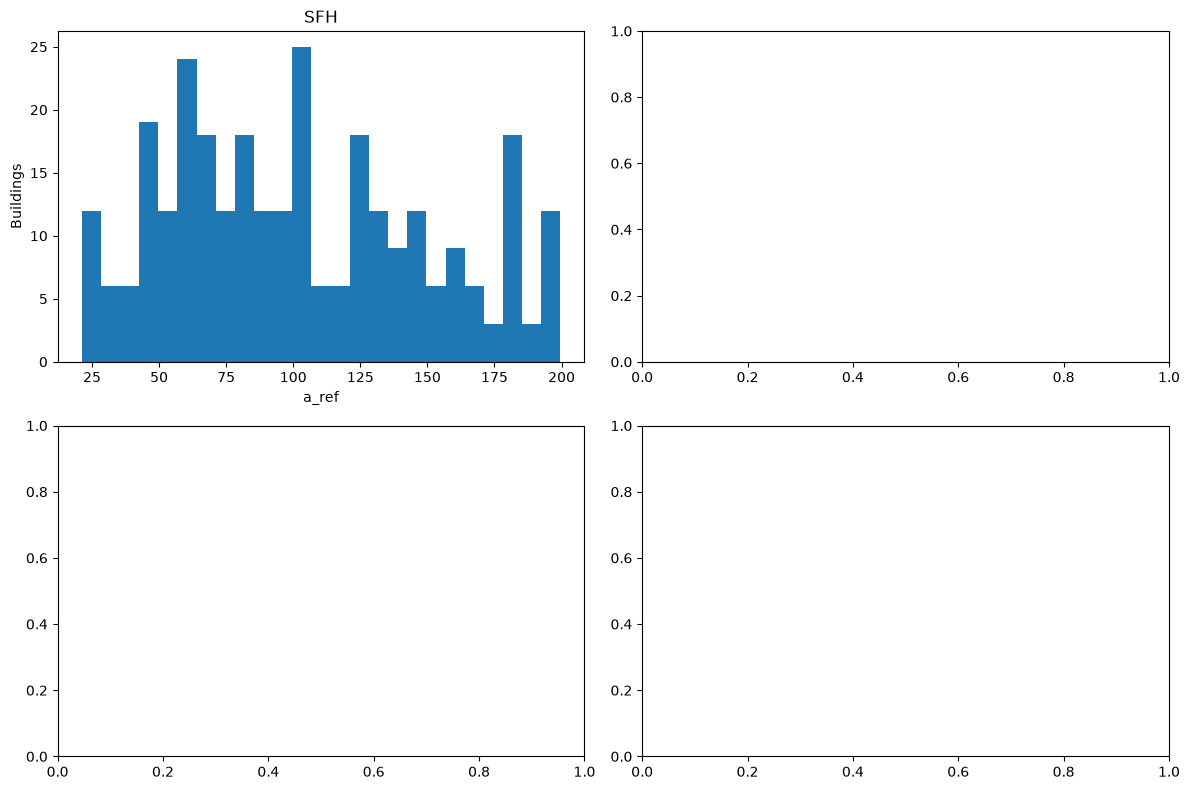

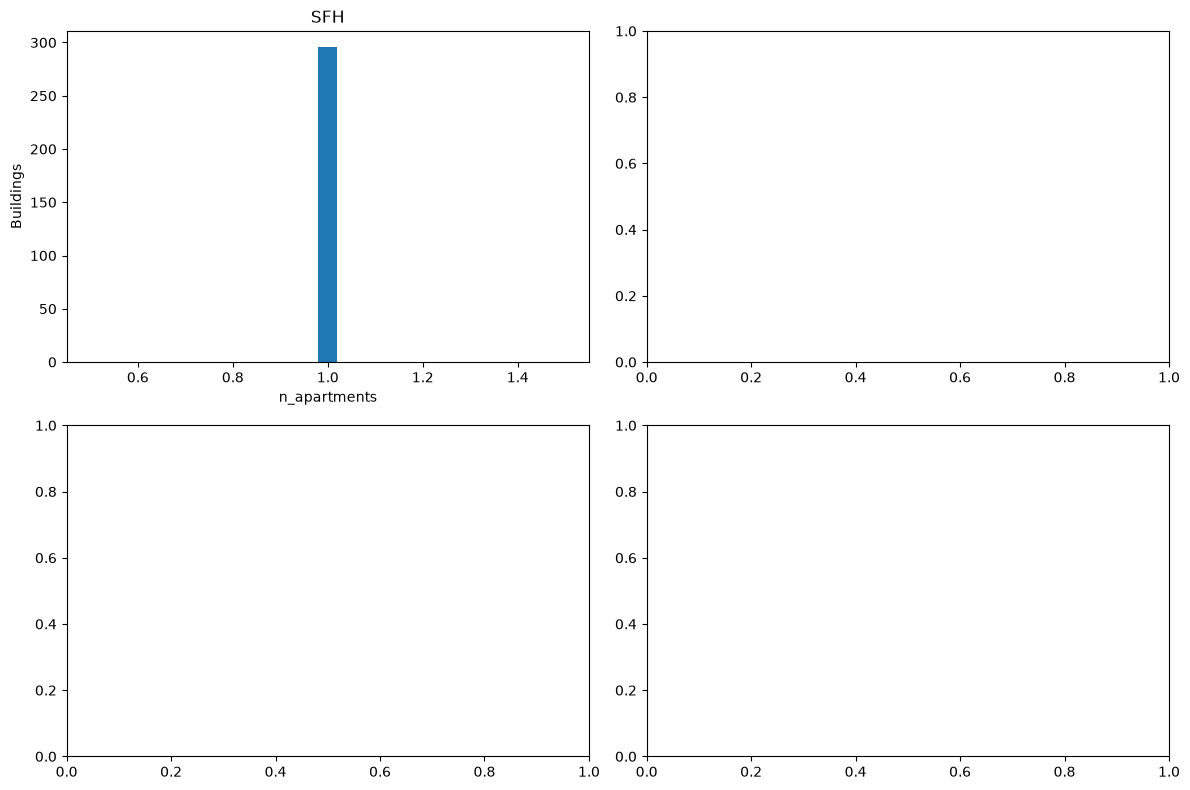

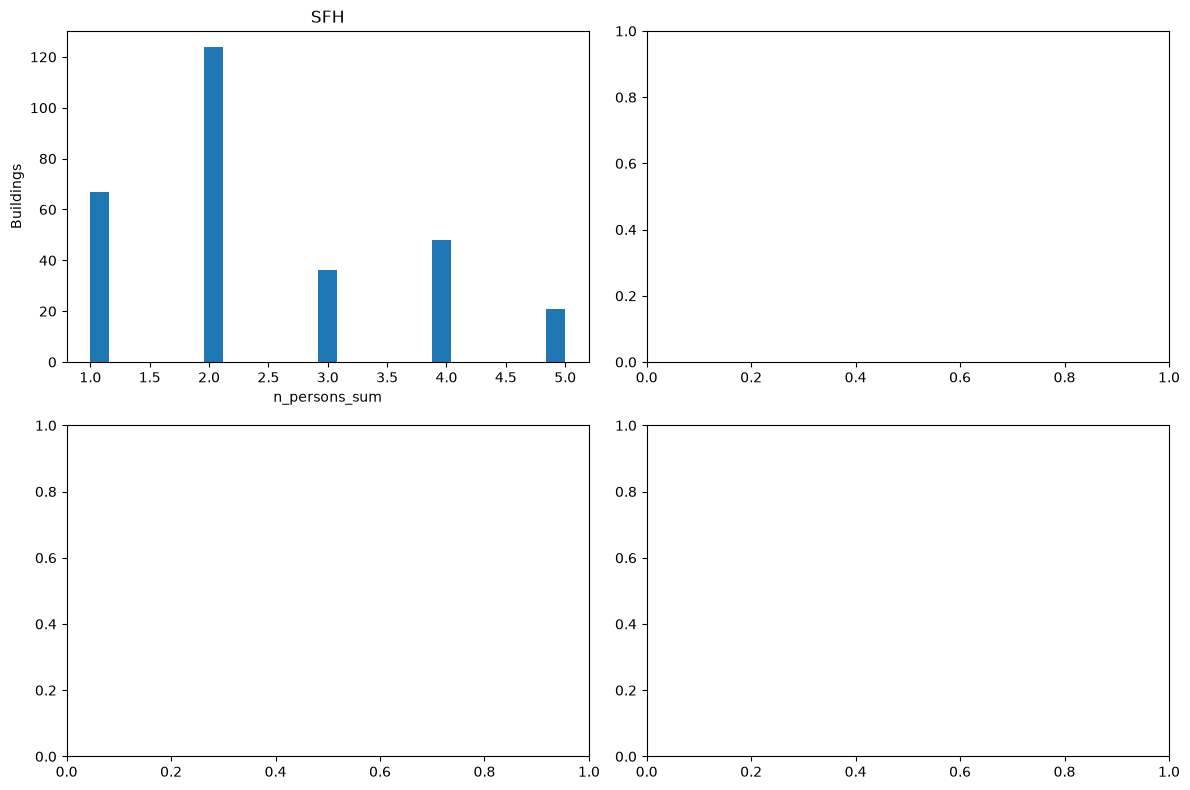

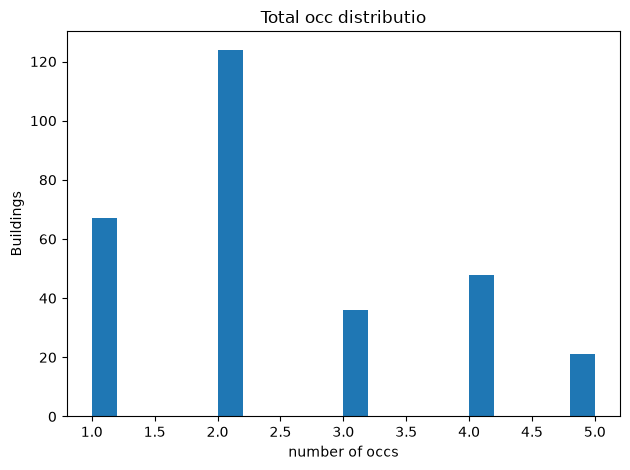

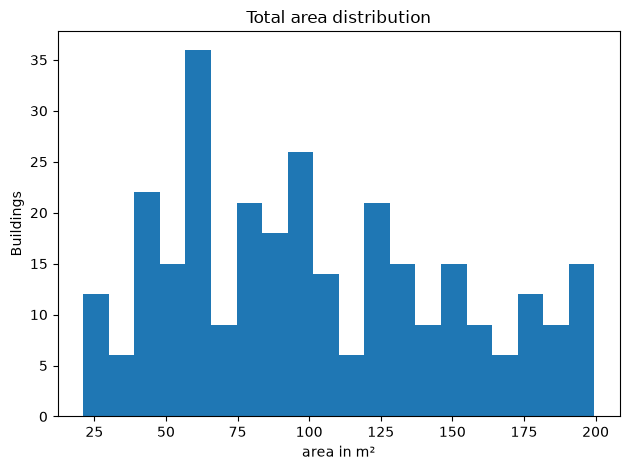

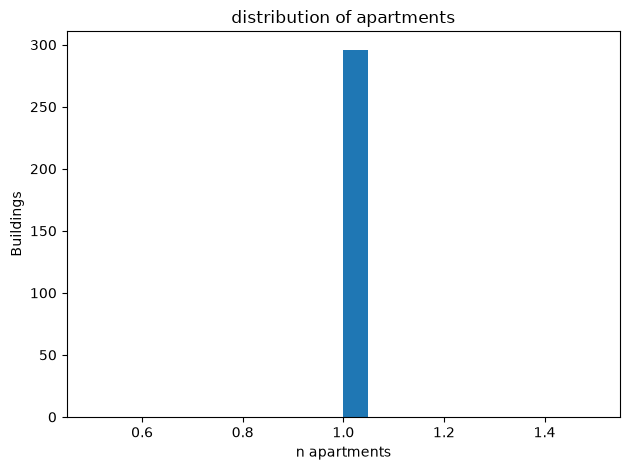

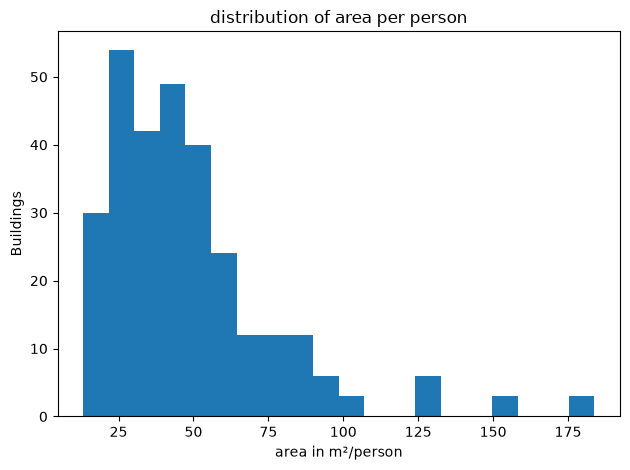

overview realized================================================================================
Overview
Rows: 296
Unique buildings: 97
Unique runs: 296
MISSING VALUES
country                   0
buildingType              0
surrounding               0
buildingAgeBin            0
a_ref                     0
n_apartments              0
year_type                 0
future                    0
climateRegion             0
n_persons                 0
freq                      0
hasFirePlace              0
varyoccupancy             0
mean_load                 0
nightReduction            0
capControl                0
occControl                0
comfortT_lb               0
comfortT_ub               0
cores                     0
useCache                  0
seed                      0
weatherFilepath           0
weatherID                 0
resolved_climateRegion    0
resolved_latitude         0
resolved_longitude        0
state_seed                0
apartment_seeds           0
maxLoadViolation_k

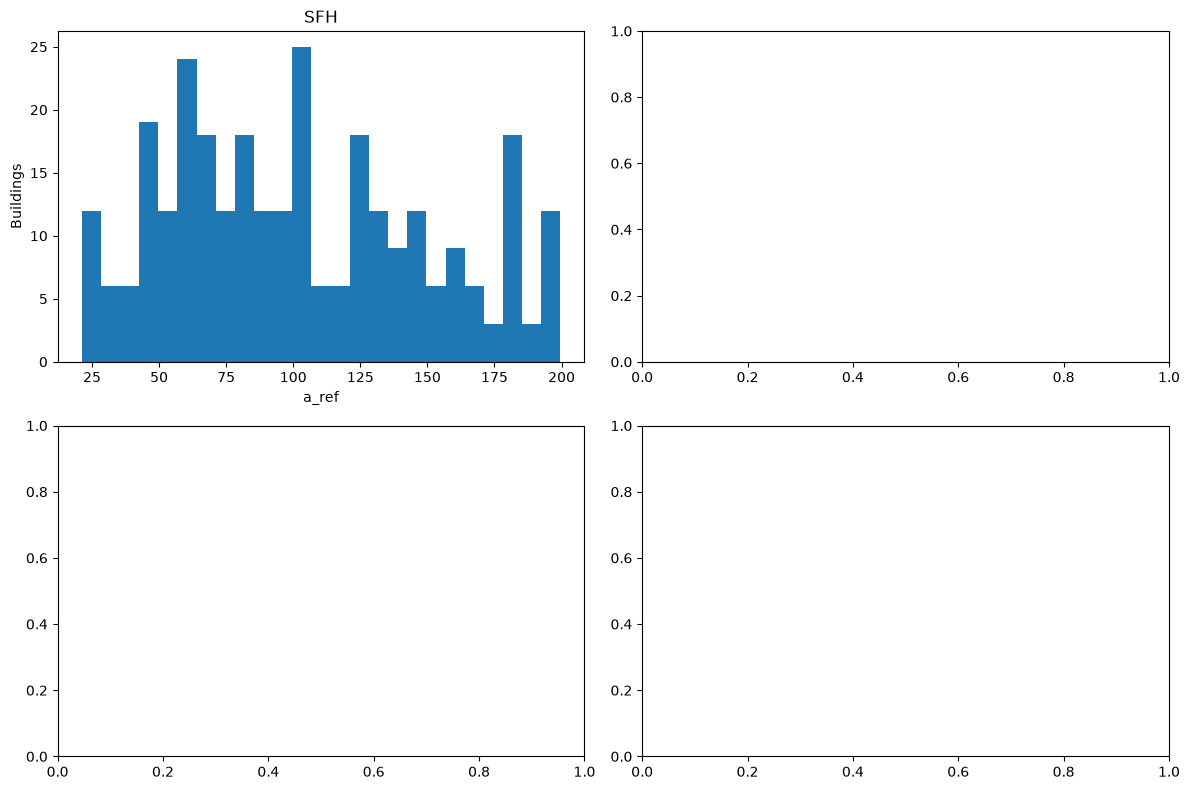

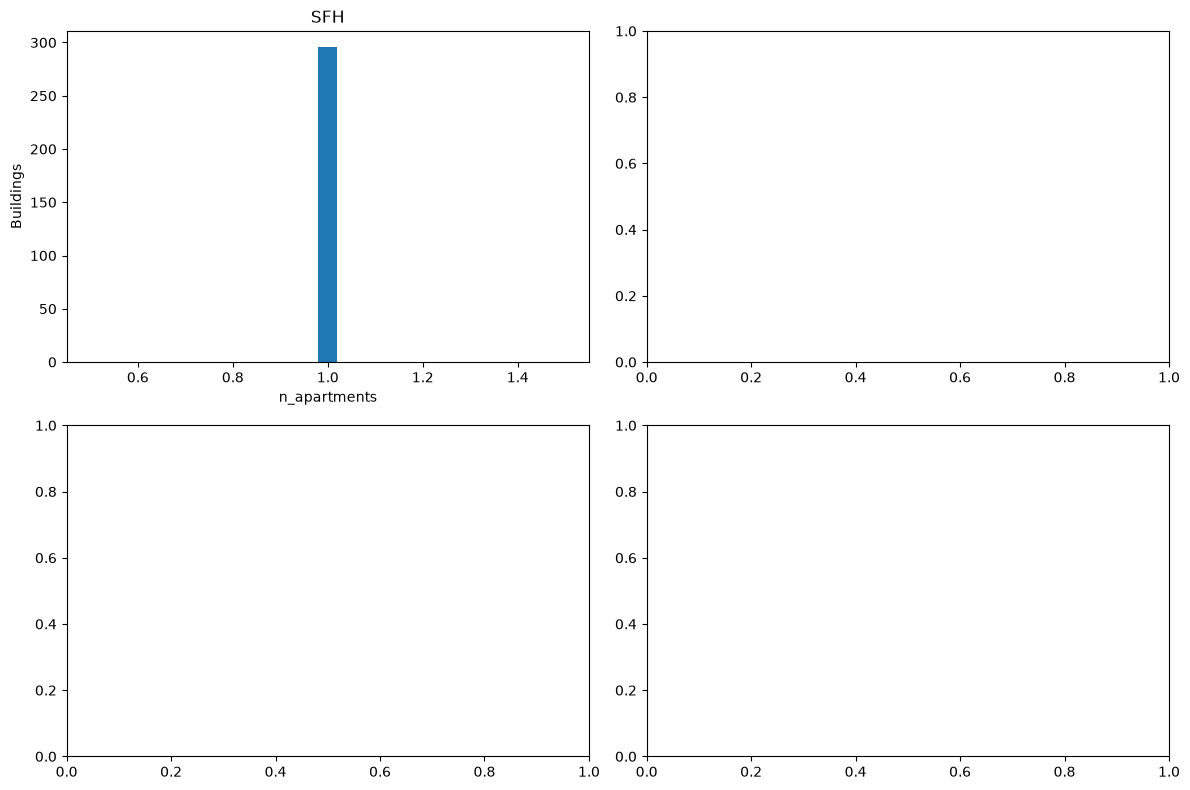

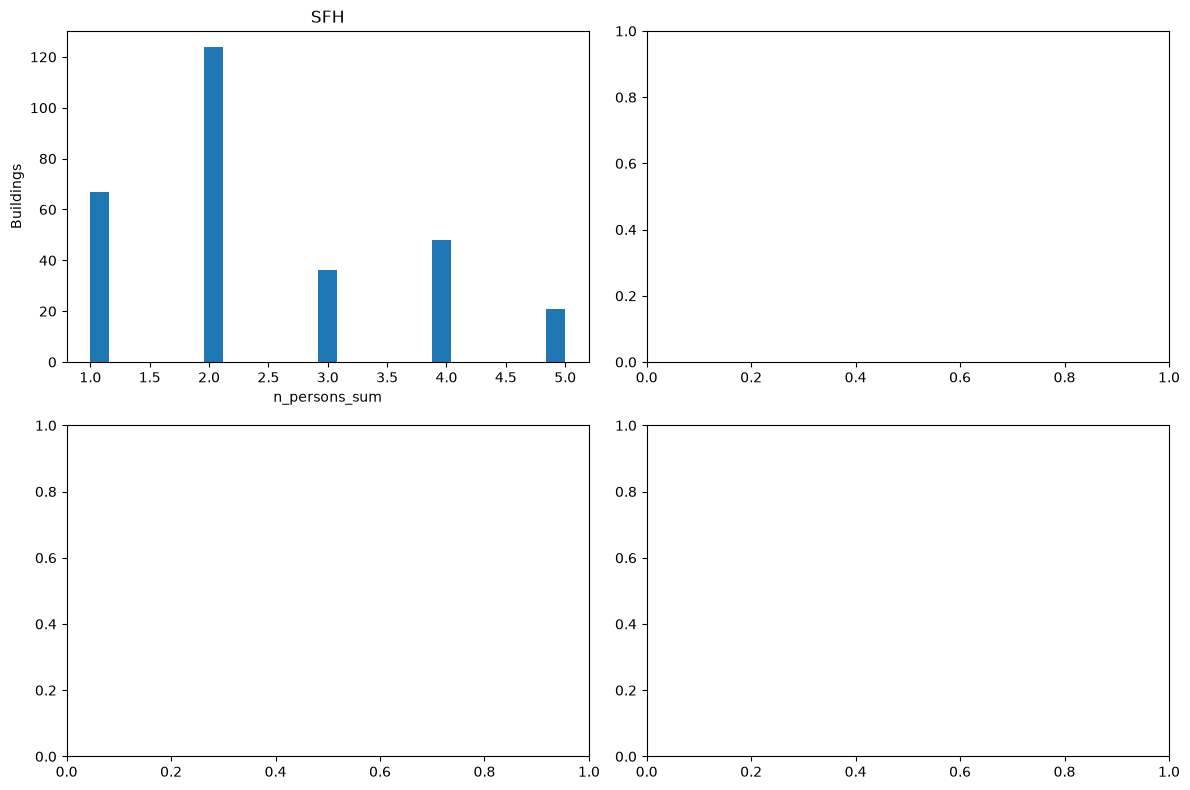

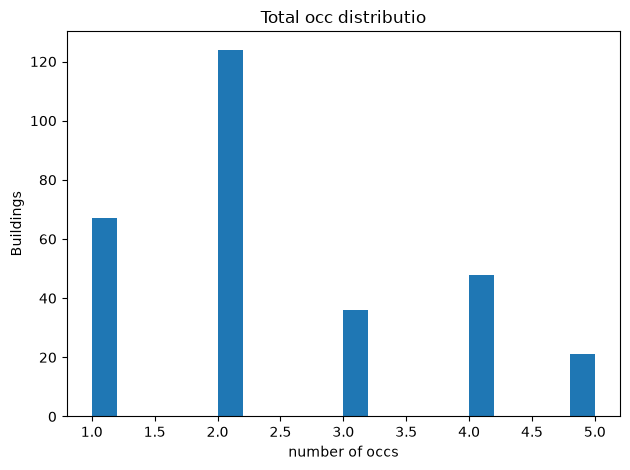

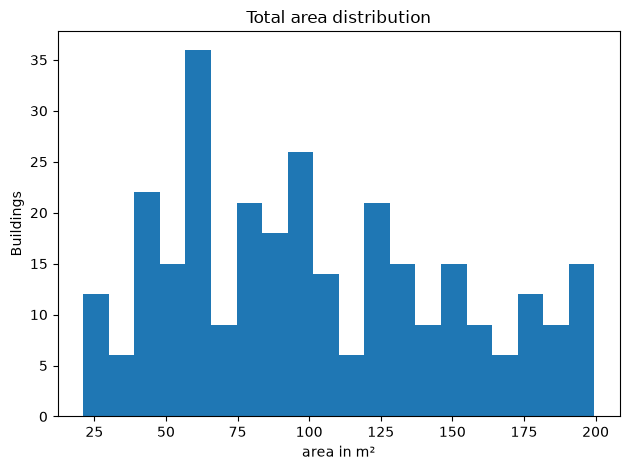

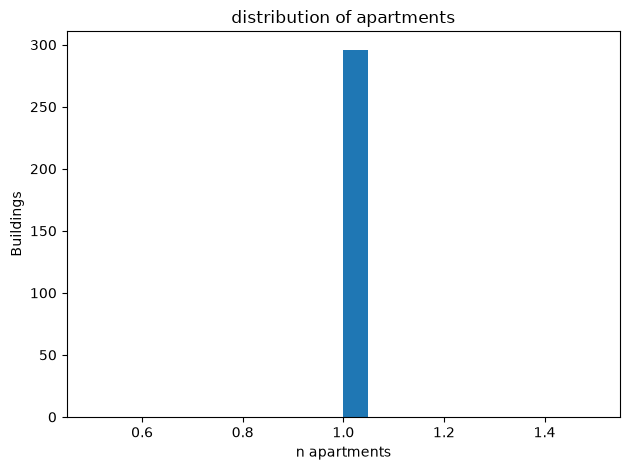

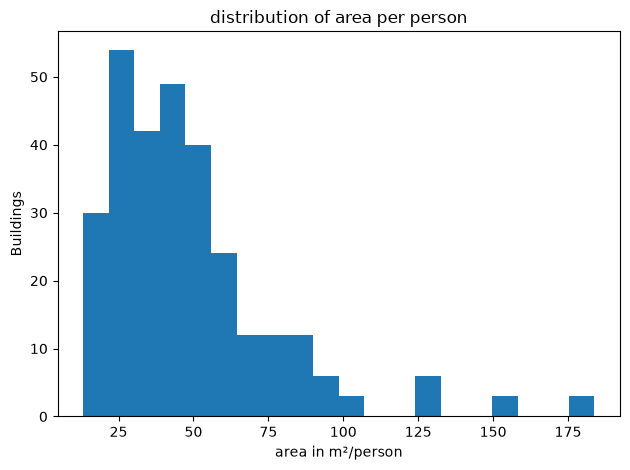

year_type  future  weatherID                                  
average    False   TRY2015_1_average_TRY2015_547234089016_Jahr    0.333333
                   TRY2015_1_average_TRY2015_537123072032_Jahr    0.333333
                   TRY2015_1_average_TRY2015_533679071939_Jahr    0.333333
cold       False   TRY2015_1_cold_TRY2015_536468076300_Wint       0.166667
                   TRY2015_1_cold_TRY2015_533679071939_Wint       0.166667
                   TRY2015_1_cold_TRY2015_539997089829_Wint       0.166667
                   TRY2015_1_cold_TRY2015_545125092740_Wint       0.166667
                   TRY2015_1_cold_TRY2015_537123072032_Wint       0.166667
                   TRY2015_1_cold_TRY2015_547234089016_Wint       0.166667
           True    TRY2045_1_cold_TRY2045_536960094598_Wint       0.333333
                   TRY2045_1_cold_TRY2045_535293084322_Wint       0.333333
                   TRY2045_1_cold_TRY2045_533096080207_Wint       0.333333
hot        False   TRY2015_1_hot_TRY2

In [16]:
comp_manifests(manifest,realised_manifest_cut)

In [18]:
check_duplicate_timeseries(realised_manifest)

Duplicated Seed Lists: False
Duplicated Seeds: <StringArray>
[]
Length: 0, dtype: str


In [19]:
ts_res = check_timeseries(RESULTS_DIR)

Checking timeseries: 100%|██████████| 300/300 [00:34<00:00,  8.67run/s]


In [20]:
ts_res


,run_id,nan_vals,neg_load_vals,total_persons,a_ref,elec_sum_yearly,elec_sum_yearly_per_occ,elec_sum_yearly_per_a_ref,elec_max,elec_min,...,temperature_p05,temperature_p95,buildingType,buildingAgeBin,surrounding,climateRegion,year_type,future,seed,state_seed
0,run_006400,False,False,2,104.9,3633.571777,1816.785889,34.638435,7.716148,0.047804,...,-6.600000,22.799999,SFH,DE.01,Detached,10,cold,False,1006400,1006400
1,run_006401,False,False,2,104.9,3313.309082,1656.654541,31.585405,8.074320,0.046097,...,-7.575000,21.646751,SFH,DE.01,Detached,10,cold,False,1006401,1006401
2,run_006402,False,False,4,165.6,3607.076660,901.769165,21.781862,8.336103,0.040975,...,-8.658334,16.434999,SFH,DE.01,Detached,15,cold,False,1006402,1006402
3,run_006403,False,False,4,165.6,3547.243896,886.810974,21.420553,6.944136,0.044390,...,-5.890083,22.620001,SFH,DE.01,Detached,15,cold,False,1006403,1006403
4,run_006404,False,False,4,165.6,3353.877197,838.469299,20.252880,9.167005,0.046097,...,-3.940000,22.553333,SFH,DE.01,Detached,15,cold,False,1006404,1006404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,run_006695,False,False,4,82.4,3275.431396,818.857849,39.750381,7.260596,0.040975,...,-0.200000,22.900000,SFH,DE.02,Detached,5,cold,True,1006695,1006695
296,run_006696,False,False,1,131.8,1947.676880,1947.676880,14.777517,7.480619,0.039268,...,-2.770000,23.325001,SFH,DE.02,Detached,4,cold,True,1006696,1006696
297,run_006697,False,False,1,131.8,1687.879517,1687.879517,12.806370,4.640358,0.040975,...,-2.770000,23.325001,SFH,DE.02,Detached,4,cold,True,1006697,1006697
298,run_006698,False,False,1,131.8,2324.243408,2324.243408,17.634623,8.566254,0.040975,...,-2.558333,24.725000,SFH,DE.02,Detached,4,cold,True,1006698,1006698


In [ ]:
ts_res.to_parquet(
    RESULTS_DIR / "timeseries_summary.parquet",
    index=False,
)